In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df = pd.read_csv(r"C:\Users\Acer\OneDrive\Desktop\weekly task\StudentsPerformance.csv")

In [10]:
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [11]:
df.shape

(1000, 8)

In [12]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='str')

In [13]:
df.dtypes

gender                           str
race/ethnicity                   str
parental level of education      str
lunch                            str
test preparation course          str
math score                     int64
reading score                  int64
writing score                  int64
dtype: object

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 103.5 KB


In [15]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [16]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df = df.drop_duplicates()

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
categorical_columns = [
    'gender',
    'race/ethnicity',
    'parental level of education',
    'lunch',
    'test preparation course'
]

for column in categorical_columns:
    print("\n", column)
    print(df[column].value_counts())


 gender
gender
female    518
male      482
Name: count, dtype: int64

 race/ethnicity
race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64

 parental level of education
parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

 lunch
lunch
standard        645
free/reduced    355
Name: count, dtype: int64

 test preparation course
test preparation course
none         642
completed    358
Name: count, dtype: int64


In [21]:

score_columns = [
    'math score',
    'reading score',
    'writing score'
]

df[score_columns].describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [22]:
df['Total Score'] = (
    df['math score'] +
    df['reading score'] +
    df['writing score']
)

In [23]:
df[['math score', 'reading score', 'writing score', 'Total Score']].head()

,math score,reading score,writing score,Total Score
0,72,72,74,218
1,69,90,88,247
2,90,95,93,278
3,47,57,44,148
4,76,78,75,229


In [24]:
df['Average Score'] = df[
    ['math score', 'reading score', 'writing score']
].mean(axis=1)

In [25]:
df[['Total Score', 'Average Score']].head()

,Total Score,Average Score
0,218,72.666667
1,247,82.333333
2,278,92.666667
3,148,49.333333
4,229,76.333333


In [26]:
df['Percentage Performance'] = (
    df['Total Score'] / 300
) * 100

In [27]:
df[['Total Score', 'Average Score', 'Percentage Performance']].head()

,Total Score,Average Score,Percentage Performance
0,218,72.666667,72.666667
1,247,82.333333,82.333333
2,278,92.666667,92.666667
3,148,49.333333,49.333333
4,229,76.333333,76.333333


In [29]:
df['Pass/Fail'] = np.where(
    (df['math score'] >= 40) &
    (df['reading score'] >= 40) &
    (df['writing score'] >= 40),
    'Pass',
    'Fail'
)

In [30]:
df['Pass/Fail'].value_counts()

Pass/Fail
Pass    949
Fail     51
Name: count, dtype: int64

In [31]:
print("Mean:")
print(df[score_columns].mean())

print("\nMedian:")
print(df[score_columns].median())

print("\nStandard Deviation:")
print(df[score_columns].std())

Mean:
math score       66.089
reading score    69.169
writing score    68.054
dtype: float64

Median:
math score       66.0
reading score    70.0
writing score    69.0
dtype: float64

Standard Deviation:
math score       15.163080
reading score    14.600192
writing score    15.195657
dtype: float64


In [32]:
print(df[score_columns].quantile([0.25, 0.50, 0.75]))

      math score  reading score  writing score
0.25        57.0           59.0          57.75
0.50        66.0           70.0          69.00
0.75        77.0           79.0          79.00


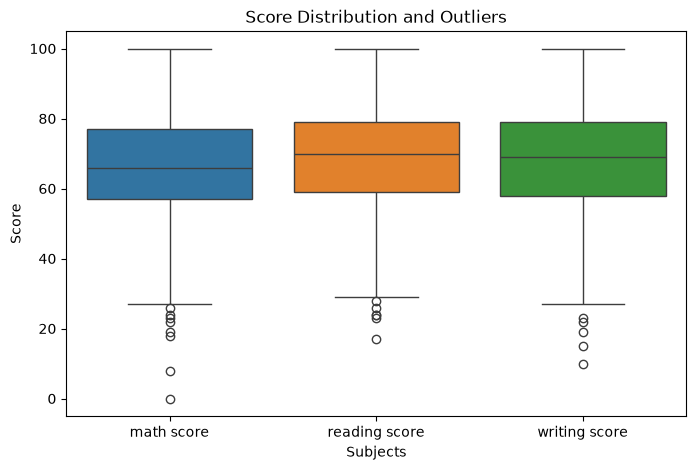

In [33]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df[score_columns]
)

plt.title("Score Distribution and Outliers")
plt.xlabel("Subjects")
plt.ylabel("Score")

plt.show()

In [34]:
parental_avg = df.groupby(
    'parental level of education'
)[score_columns].mean()

parental_avg

,math score,reading score,writing score
parental level of education,,,
associate's degree,67.882883,70.927928,69.896396
bachelor's degree,69.389831,73.000000,73.381356
high school,62.137755,64.704082,62.448980
master's degree,69.745763,75.372881,75.677966
some college,67.128319,69.460177,68.840708
some high school,63.497207,66.938547,64.888268


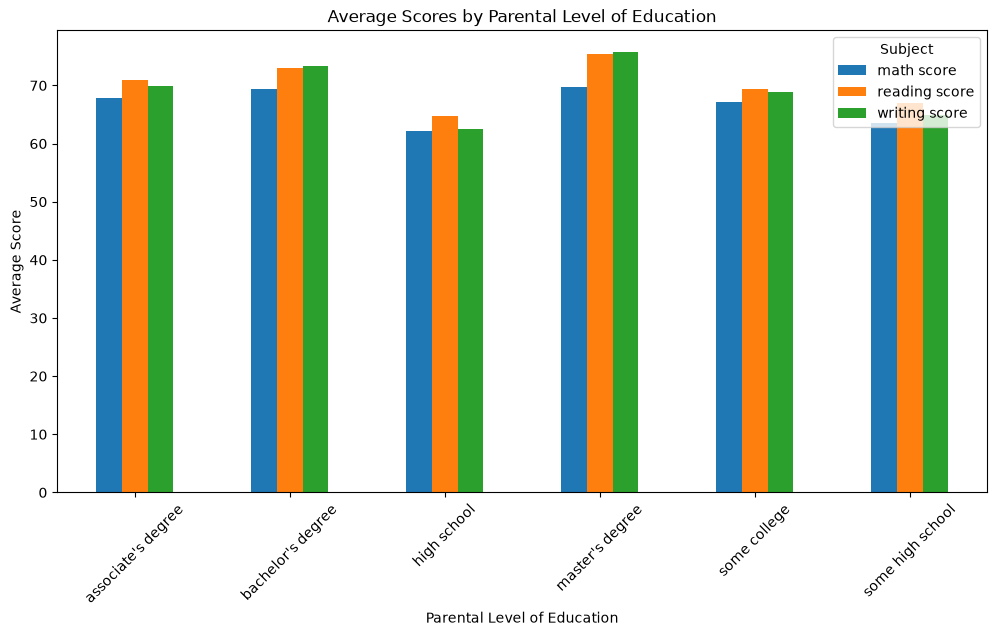

In [35]:
parental_avg.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title("Average Scores by Parental Level of Education")
plt.xlabel("Parental Level of Education")
plt.ylabel("Average Score")
plt.xticks(rotation=45)
plt.legend(title="Subject")

plt.show()

In [36]:
lunch_avg = df.groupby('lunch')[score_columns].mean()

lunch_avg

,math score,reading score,writing score
lunch,,,
free/reduced,58.921127,64.653521,63.022535
standard,70.034109,71.654264,70.823256


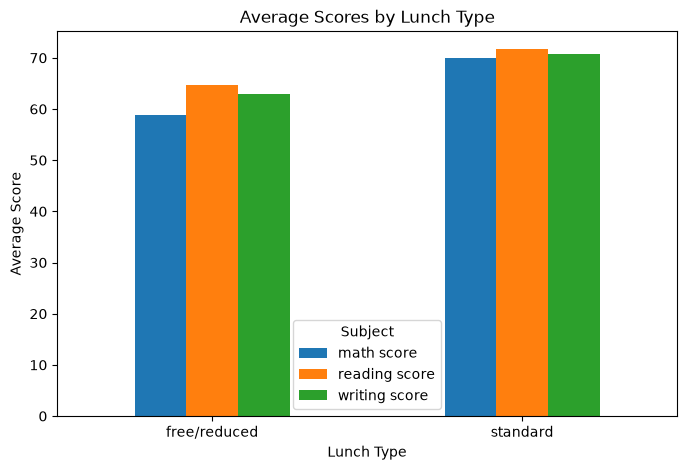

In [37]:
lunch_avg.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title("Average Scores by Lunch Type")
plt.xlabel("Lunch Type")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.legend(title="Subject")

plt.show()

In [38]:
test_prep_avg = df.groupby(
    'test preparation course'
)[score_columns].mean()

test_prep_avg

,math score,reading score,writing score
test preparation course,,,
completed,69.695531,73.893855,74.418994
none,64.077882,66.534268,64.504673


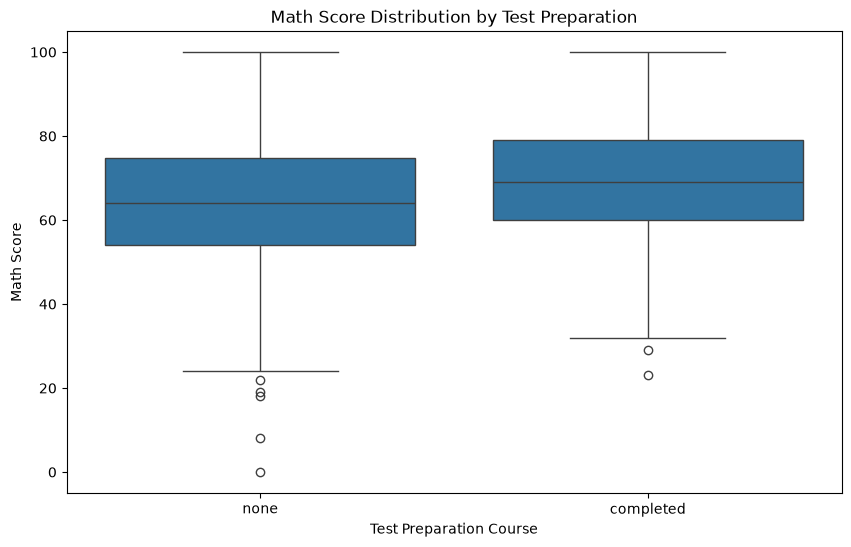

In [39]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='test preparation course',
    y='math score'
)

plt.title("Math Score Distribution by Test Preparation")
plt.xlabel("Test Preparation Course")
plt.ylabel("Math Score")

plt.show()

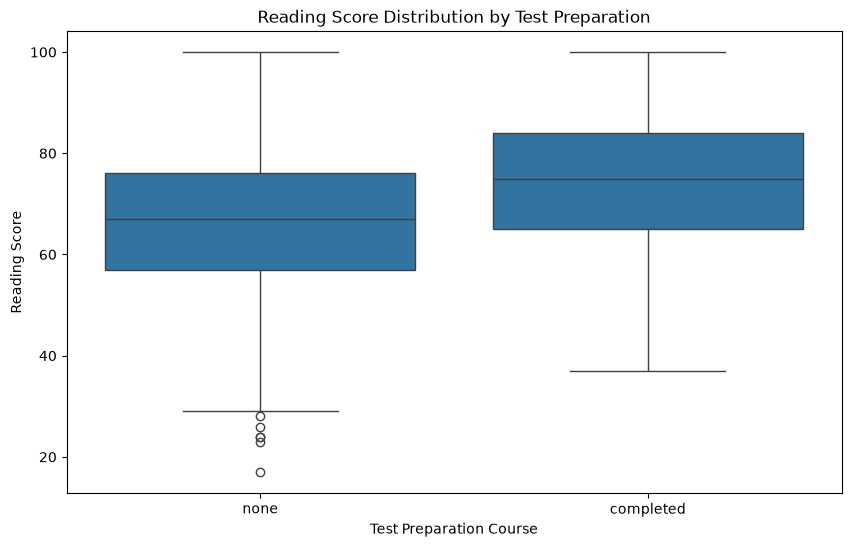

In [40]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='test preparation course',
    y='reading score'
)

plt.title("Reading Score Distribution by Test Preparation")
plt.xlabel("Test Preparation Course")
plt.ylabel("Reading Score")

plt.show()

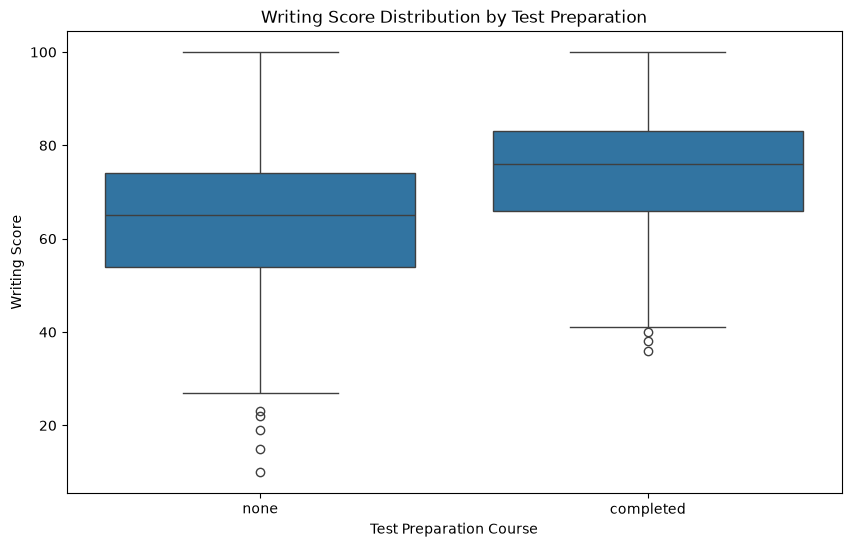

In [41]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='test preparation course',
    y='writing score'
)

plt.title("Writing Score Distribution by Test Preparation")
plt.xlabel("Test Preparation Course")
plt.ylabel("Writing Score")

plt.show()

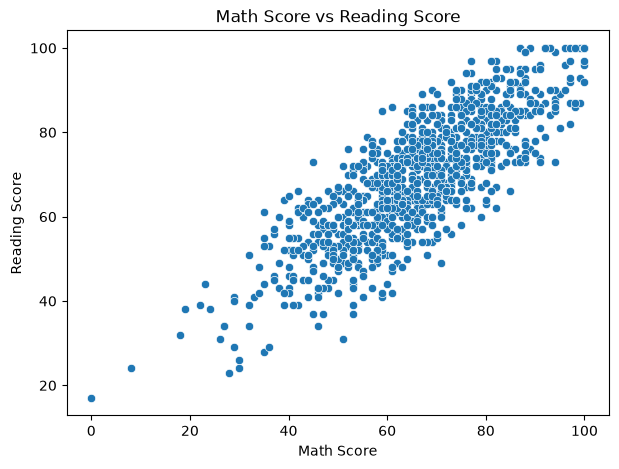

In [42]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x='math score',
    y='reading score'
)

plt.title("Math Score vs Reading Score")
plt.xlabel("Math Score")
plt.ylabel("Reading Score")

plt.show()

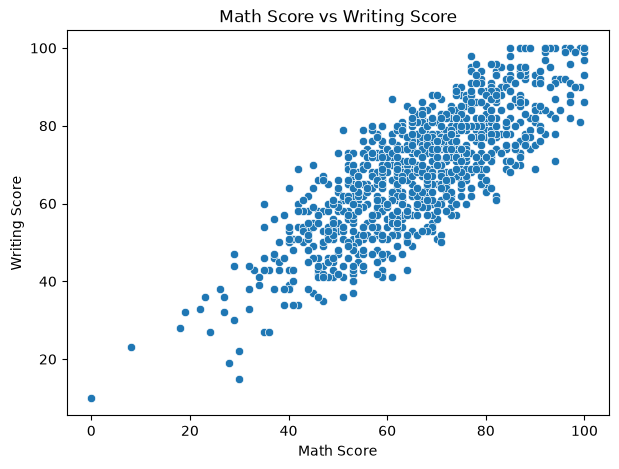

In [43]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x='math score',
    y='writing score'
)

plt.title("Math Score vs Writing Score")
plt.xlabel("Math Score")
plt.ylabel("Writing Score")

plt.show()

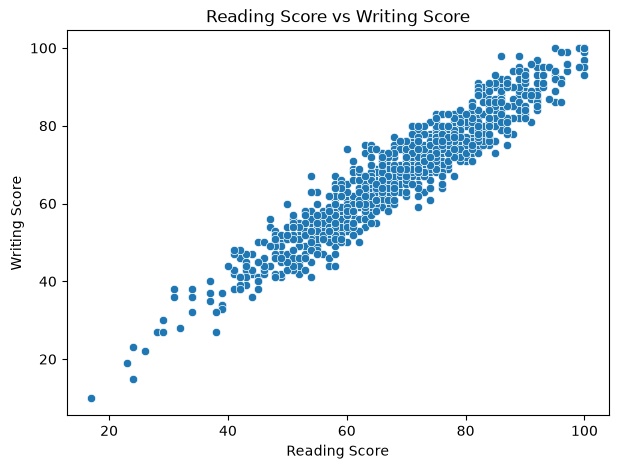

In [44]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x='reading score',
    y='writing score'
)

plt.title("Reading Score vs Writing Score")
plt.xlabel("Reading Score")
plt.ylabel("Writing Score")

plt.show()

In [45]:
correlation_matrix = df[
    ['math score', 'reading score', 'writing score']
].corr()

correlation_matrix

,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


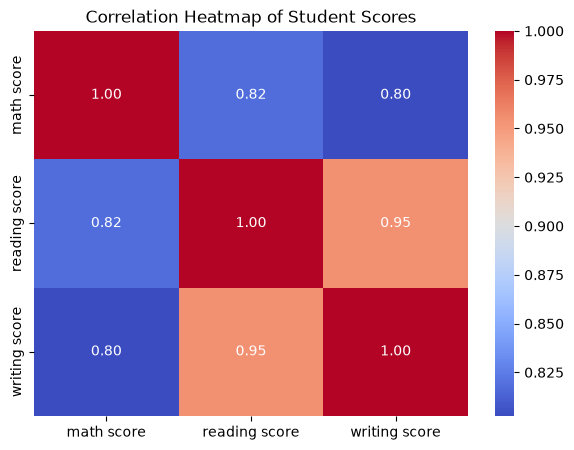

In [46]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap of Student Scores")

plt.show()

In [47]:
gender_avg = df.groupby('gender')[score_columns].mean()

gender_avg

,math score,reading score,writing score
gender,,,
female,63.633205,72.608108,72.467181
male,68.728216,65.473029,63.311203


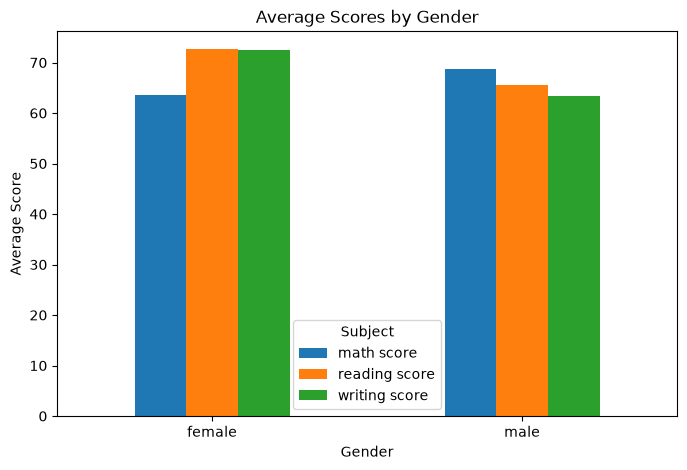

In [48]:
gender_avg.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title("Average Scores by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.legend(title="Subject")

plt.show()

In [49]:
race_avg = df.groupby(
    'race/ethnicity'
)[score_columns].mean()

race_avg

,math score,reading score,writing score
race/ethnicity,,,
group A,61.629213,64.674157,62.674157
group B,63.452632,67.352632,65.600000
group C,64.463950,69.103448,67.827586
group D,67.362595,70.030534,70.145038
group E,73.821429,73.028571,71.407143


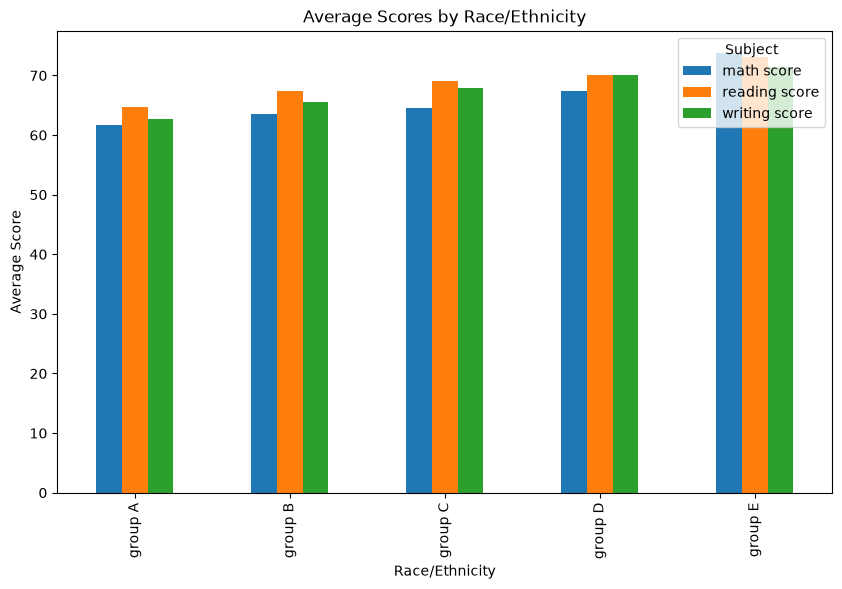

In [50]:
race_avg.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title("Average Scores by Race/Ethnicity")
plt.xlabel("Race/Ethnicity")
plt.ylabel("Average Score")
plt.legend(title="Subject")

plt.show()

In [51]:
total_by_prep = df.groupby(
    'test preparation course'
)['Total Score'].mean()

total_by_prep

test preparation course
completed    218.008380
none         195.116822
Name: Total Score, dtype: float64

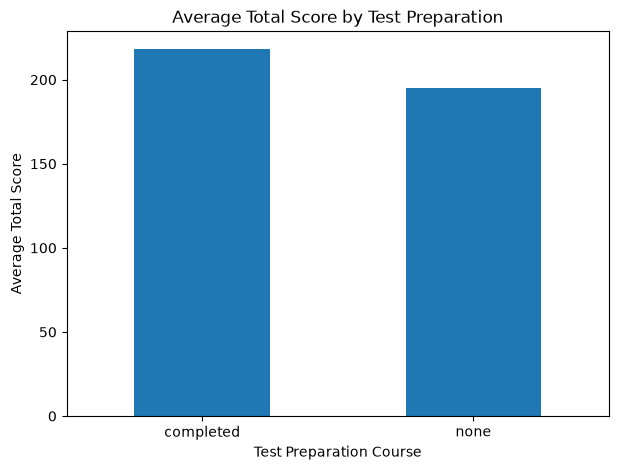

In [52]:
total_by_prep.plot(
    kind='bar',
    figsize=(7, 5)
)

plt.title("Average Total Score by Test Preparation")
plt.xlabel("Test Preparation Course")
plt.ylabel("Average Total Score")
plt.xticks(rotation=0)

plt.show()

In [53]:
average_by_prep = df.groupby(
    'test preparation course'
)['Average Score'].mean()

average_by_prep

test preparation course
completed    72.669460
none         65.038941
Name: Average Score, dtype: float64

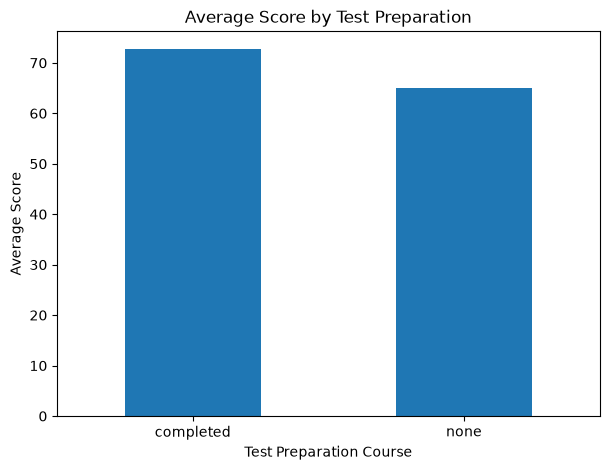

In [54]:
average_by_prep.plot(
    kind='bar',
    figsize=(7, 5)
)

plt.title("Average Score by Test Preparation")
plt.xlabel("Test Preparation Course")
plt.ylabel("Average Score")
plt.xticks(rotation=0)

plt.show()

In [58]:
df.to_csv(
    "student_performance_week8_final.csv",
    index=False
)

Business Insights Questions and Answers

1. Overall Performance

1. Which subject has the highest average score?
Reading has the highest average score, with an average of approximately 69.17.

2. Which subject has the lowest average score?
Math has the lowest average score, with an average of approximately 66.09.

3. What is the average overall student performance?
The average overall student performance is approximately 67.77.

4. Which subject shows the greatest variation in scores?
Writing shows the greatest variation, with a standard deviation of approximately 15.20.

5. Are the score distributions similar across Math, Reading, and Writing?
Yes. The three subjects have broadly similar score distributions, although their averages and variations differ slightly. Reading has the highest average, while Math has the lowest average.

---

2. Parental Level of Education

6. How does average performance vary across parental education levels?
Average performance generally increases with higher parental education levels. Students whose parents have Master's or Bachelor's degrees show higher average scores than students whose parents have only a High School education.

7. Which parental education group has the highest average scores?
The Master's Degree group has the highest overall average score, approximately 73.60.

8. Which subject shows the largest variation across parental education groups?
Math shows the largest variation across parental education groups based on the differences in group averages.

9. Are there noticeable differences in overall performance between groups?
Yes. Noticeable differences can be observed. The Master's Degree group has the highest average, while the High School group has the lowest average.

---

3. Lunch Type

10. How does academic performance vary across lunch categories?
Students receiving Standard Lunch have higher average scores than students receiving Free or Reduced Lunch across all three subjects.

11. Which lunch group has the higher average score?
The Standard Lunch group has the higher average score.

12. Are differences consistent across Math, Reading, and Writing?
Yes. The Standard Lunch group has higher average scores in Math, Reading, and Writing.

13. What observations can be made from the box plots and bar charts?
The bar charts show higher average scores for the Standard Lunch group. The box plots show differences in the distributions, including differences in median scores and score spread between the groups.

---

4. Test Preparation

14. How do students who completed test preparation compare with those who did not?
Students who completed test preparation generally have higher average scores in Math, Reading, and Writing than students who did not complete it.

15. Which subject shows the largest difference between the two groups?
Writing shows the largest difference between the test preparation groups.

16. How does Total Score vary between the two groups?
Students who completed test preparation have a higher average Total Score. Their average Total Score is approximately 218.01 out of 300.

17. How does Average Score vary between the two groups?
Students who completed test preparation have a higher Average Score of approximately 72.67.

18. What does the box plot reveal about score distributions?
The box plot shows that the test-preparation group generally has higher median scores and a different score distribution compared with the group that did not complete test preparation.

19. Can the observed difference be interpreted as causation from this dataset alone?
No. The dataset is observational, so it can show an association between test preparation and scores, but it cannot prove that test preparation alone caused the higher scores.

---

5. Gender and Race/Ethnicity

20. How do average scores vary across gender groups?
Female students have higher average Reading and Writing scores, while male students have a higher average Math score. The overall averages are approximately 69.57 for females and 65.84 for males.

21. How do scores vary across race/ethnicity groups?
Average scores differ across the race/ethnicity groups. Group A has the lowest overall average of approximately 62.99, while Group E has the highest overall average of approximately 72.75.

22. Which subjects show the largest differences between groups?
Differences can be observed across all three subjects. The largest differences vary depending on the demographic comparison, but Math and Writing show noticeable differences across several groups.

23. Which groups may require further investigation or additional academic support?
Groups with comparatively lower average scores may require further investigation and academic support. However, demographic categories alone should not be used to assume that a student needs support. Individual performance and other educational factors should also be considered.

---

6. Subject Relationships

24. Is there a relationship between Math and Reading scores?
Yes. Math and Reading have a strong positive correlation of approximately 0.818.

25. Is there a relationship between Math and Writing scores?
Yes. Math and Writing have a strong positive correlation of approximately 0.803.

26. Is there a relationship between Reading and Writing scores?
Yes. Reading and Writing have a very strong positive correlation of approximately 0.955.

27. Which pair of subjects has the strongest correlation?
Reading and Writing have the strongest correlation, with a correlation coefficient of approximately 0.955.

28. What does the correlation heatmap indicate?
The heatmap indicates strong positive relationships among Math, Reading, and Writing. Students who perform well in one subject generally tend to perform well in the other subjects.

---

7. Educational Insights

29. What are the major patterns in student performance?
The major patterns are that Reading has the highest average score, Math has the lowest average score, and all three subjects are strongly positively correlated. Differences are also observed across parental education, lunch type, test preparation, gender, and race/ethnicity groups.

30. Which demographic factors show noticeable differences in academic outcomes?
Parental education level and lunch type show noticeable differences in average academic performance. Differences are also observed across gender and race/ethnicity groups.

31. What patterns are observed in relation to test preparation?
Students who completed test preparation generally have higher Math, Reading, and Writing scores than students who did not complete it. The completed group has an average score of approximately 72.67.

32. What areas may require further educational investigation?
Further investigation may focus on lower-performing students, Math performance, socioeconomic differences, access to test preparation, and the reasons behind differences between demographic groups. Additional factors such as attendance, study time, previous achievement, and access to learning resources could also be studied.

33. What recommendations can be proposed based on the observed data?
Schools can provide targeted Math support, improve access to test preparation resources, identify students who need early academic assistance, and examine whether socioeconomic factors affect access to educational resources. Support should be based on individual academic needs rather than demographic categories alone. Further analysis with additional variables would also help understand the causes behind the observed patterns.

The project titled “Student Performance Visualization, Demographic Analysis & Educational Insights” focuses on analyzing student academic performance using a Student Performance Dataset. The main purpose of this project is to understand the overall performance of students and identify how demographic and educational factors such as gender, race or ethnicity, parental level of education, lunch type, and test preparation are associated with academic outcomes. Data analysis and visualization techniques are used to identify important patterns, relationships, performance differences, and possible educational insights from the dataset.

The dataset contains information about 1,000 students and includes categorical attributes such as Gender, Race/Ethnicity, Parental Level of Education, Lunch, and Test Preparation Course, along with the numerical scores of Math, Reading, and Writing. Python was used as the main programming language for the analysis. Pandas was used for data loading, cleaning, manipulation, and statistical analysis, while NumPy was used for numerical operations. Matplotlib and Seaborn were used to create different visualizations such as bar charts, box plots, scatter plots, and correlation heatmaps.

The dataset was first loaded into a Pandas DataFrame and examined using functions such as head(), shape, columns, dtypes, info(), and describe(). The dataset was checked for missing values and duplicate records. Categorical columns were examined using value counts, and numerical columns were analyzed to understand their statistical distribution. The Math, Reading, and Writing scores were selected as the major academic performance measures for the analysis.

Feature engineering was performed to create additional performance-related columns. A Total Score was calculated by adding the Math, Reading, and Writing scores. An Average Score was calculated by dividing the total score by three. Percentage Performance was also calculated based on the total possible score. A Pass or Fail classification was created using a minimum score criterion of 40 marks in each subject. These additional features helped in understanding the overall academic performance of students more clearly.

The descriptive statistical analysis showed that the average Math score was approximately 66.09, the average Reading score was approximately 69.17, and the average Writing score was approximately 68.05. Therefore, Reading had the highest average score among the three subjects, while Math had the lowest average. The overall average performance was approximately 67.77. The standard deviations of Math, Reading, and Writing were approximately 15.16, 14.60, and 15.20 respectively, showing that student scores had noticeable variation across all three subjects.

The analysis of parental education showed differences in average student performance across parental education groups. Students whose parents had a Master's Degree had an overall average of approximately 73.60, while students whose parents had a Bachelor's Degree had an overall average of approximately 71.92. Students with parents having an Associate's Degree had an average of approximately 69.57, followed by Some College at approximately 68.48. Students whose parents had Some High School education had an average of approximately 65.11, while the High School group had an average of approximately 63.10. This pattern shows an association between parental education level and student academic performance in this dataset.

Lunch type also showed a noticeable difference in academic performance. Students receiving Standard Lunch had an average Math score of approximately 70.03, Reading score of 71.65, and Writing score of 70.82. Students receiving Free or Reduced Lunch had average scores of approximately 58.92 in Math, 64.65 in Reading, and 63.02 in Writing. These results show a substantial difference between the two lunch groups. However, the result represents an association in the dataset and should not be interpreted as proof that lunch type itself causes differences in academic performance.

Test preparation was another important factor analyzed in the project. Approximately 358 students were recorded as having completed the test preparation course, while the remaining records had no completed test preparation entry. For analysis, the blank or missing test preparation entries were treated as students who had not completed the preparation course. Students who completed the test preparation course had average scores of approximately 69.70 in Math, 73.89 in Reading, and 74.42 in Writing. Their average total score was approximately 218.01 out of 300, with an average score of approximately 72.67. The completed test preparation group therefore showed higher average academic scores. Since this is observational data, the analysis identifies an association and does not establish that test preparation alone caused the higher scores.

Gender-based analysis showed different patterns across subjects. Female students had an average Math score of approximately 63.63, Reading score of 72.61, and Writing score of 72.47, giving an overall average of approximately 69.57. Male students had an average Math score of approximately 68.73, Reading score of 65.47, and Writing score of 63.31, giving an overall average of approximately 65.84. The results indicate that the two groups showed different subject-level performance patterns, particularly in Math compared with Reading and Writing.

Race or ethnicity analysis also showed differences in average performance among the groups. Group A had an overall average of approximately 62.99, Group B had approximately 65.47, Group C had approximately 67.13, Group D had approximately 69.18, and Group E had approximately 72.75. These differences indicate variation in average academic performance among the demographic groups in this dataset. Such differences should be interpreted carefully because demographic categories themselves do not explain the causes of academic outcomes, and other social, educational, economic, and institutional factors may contribute to the observed differences.

The project also examined relationships between the three academic subjects using scatter plots and correlation analysis. The correlation between Math and Reading was approximately 0.818, while the correlation between Math and Writing was approximately 0.803. The strongest relationship was between Reading and Writing, with a correlation of approximately 0.955. These strong positive correlations indicate that students who performed well in one subject generally tended to perform well in the other subjects as well. The particularly strong Reading-Writing relationship suggests that literacy-related skills may be closely connected in the dataset. However, correlation does not prove causation.

Different visualizations were created to make the analysis easier to understand. Grouped bar charts were used to compare average academic scores across parental education and lunch categories. Box plots were used to compare Math, Reading, and Writing scores between students who completed test preparation and those who did not. Scatter plots were used to examine relationships between Math, Reading, and Writing scores. A correlation matrix and heatmap were used to display the strength and direction of relationships among the numerical variables. These visualizations helped identify patterns that may not be immediately visible from numerical tables alone.

The analysis provides several educational insights. First, Reading had the highest average score among the three subjects, while Math had the lowest average. Second, students from different parental education groups showed differences in average performance. Third, students receiving Standard Lunch had higher average scores than students receiving Free or Reduced Lunch in this dataset, highlighting the need to consider socioeconomic factors when studying educational outcomes. Fourth, students who completed test preparation showed higher average scores across the three subjects. Fifth, strong positive relationships were found among Math, Reading, and Writing, particularly between Reading and Writing.

Based on these observations, educational institutions can consider several possible areas for improvement. Students who show lower performance in Math may benefit from additional practice, mentoring, and targeted academic support. Schools can also examine whether students from economically disadvantaged backgrounds have equal access to learning materials, academic support, and preparation resources. Test preparation opportunities could be made more accessible to students who may not otherwise have access to them. Early identification of students with consistently low scores can help institutions provide support before academic difficulties become larger problems. Since Reading and Writing showed a very strong relationship, integrated literacy activities may also support students across multiple subjects.

The analysis has some limitations. The dataset is observational, so the relationships found in the analysis should not be interpreted as causal effects. Missing values in the Test Preparation Course column were treated as students who had not completed the course, which may affect the comparison if missing values had another meaning. The dataset also does not include several potentially important factors such as attendance, study hours, previous academic performance, teaching quality, school resources, family support, or access to learning technology. Group averages can also hide differences between individual students.

In conclusion, the Student Performance Dataset provides useful information for understanding academic performance and demographic patterns. The analysis showed differences in performance across parental education, lunch type, test preparation, gender, and race or ethnicity groups. It also showed strong relationships between Math, Reading, and Writing scores, with Reading and Writing having the strongest correlation. Data visualization made these patterns easier to identify and interpret. Overall, the project demonstrates how Python, Pandas, NumPy, Matplotlib, and Seaborn can be used to transform raw educational data into meaningful statistical and visual insights that can support further educational analysis and informed decision-making.